In [1]:
import numpy as np
from scipy.integrate import quad
from scipy.stats import poisson,norm 
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import brentq

Simple model for a flat background and exponential signal

In [2]:
def bkg_model(x):
    return 1.0
def sig_model(x):
    return np.exp(-x/3.)

Find the bin-by-bin expectation for signal and background

Have a function that samples accoridng to a Poisson distribution for signal + background, including systematic Gaussian smearing with 50% uncertinaty on the background

This can give negative background expectation, so we should be careful

In [6]:
x_bkg = np.array([quad(bkg_model,xl,xu)[0] for xl,xu in zip(np.linspace(0,6,3),np.linspace(3,9,3))])
x_sig = np.array([quad(sig_model,xl,xu)[0] for xl,xu in zip(np.linspace(0,6,3),np.linspace(3,9,3))])
def sample(a,b):
    x_samp = np.array([poisson.rvs(a*norm.rvs(xb,scale=0.5*xb)+b*xs) for xb,xs in zip(x_bkg,x_sig)])
    return x_samp
x = sample(2./3.,750)

In [9]:
print(x_bkg)
print(x_sig)

print(np.linspace(0,6,3))
print(np.linspace(3,9,3))

[3. 3. 3.]
[1.89636168 0.69763247 0.25664464]
[0. 3. 6.]
[3. 6. 9.]


Here, I solved manually in Mathematica for the two-bin case taking only the two upper bins (sideband) to minimize chi^2

In [14]:
def a_sol(x):
    return (x[2]*x_sig[1] - x[1]*x_sig[2])/(x_bkg[2]*x_sig[1]-x_bkg[1]*x_sig[2])
def b_sol(x):
    return (x[2]*x_bkg[1] - x[1]*x_bkg[2])/(x_bkg[1]*x_sig[2]-x_bkg[2]*x_sig[1])

Here is the definition of chi^2 I used

In [15]:
def chi2(x,a,b):
    return sum(np.square(x[1:] - a * x_bkg[1:] - b * x_sig[1:]) / ((0.5 * (2./3.) * x_bkg[1:])**2 + x[1:]))

Print out the fit values for a and b for reference

In [16]:
a_sol(x)

-1.5447633245823893

In [17]:
b_sol(x)

750.587608283406

For fun, let's construct a chi^2 = 0.1 (95% p-value) contour

In [18]:
grid_size = 200
a_list = np.linspace(0,3,grid_size)
b_list = np.linspace(500,900,grid_size)
chi_list = []
for a in a_list:
    for b in b_list:
        chi_list.append(chi2(x,a,b))
chi_list = np.array(chi_list)
chi_list = np.transpose(chi_list.reshape(grid_size,grid_size))

ValueError: x and y must have same first dimension, but have shapes (200,) and (0,)

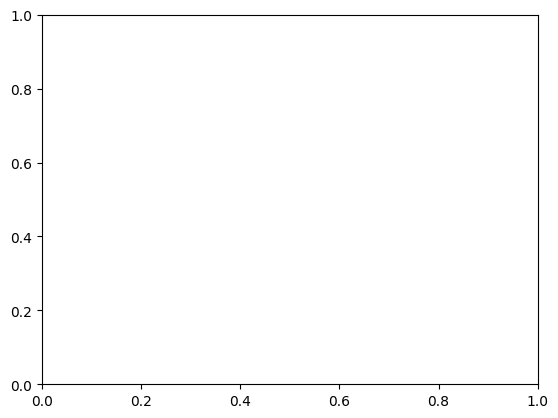

In [19]:
plt.plot(b_list,a_max)
plt.xlim(600,900)
plt.show()

plt.contourf(a_list,b_list,chi_list,levels=[0,2.41,5.99],alpha=0.5)
plt.plot([a_sol(x)],[b_sol(x)],ls='',marker='.')
plt.xlim(0.01,35)
plt.ylim(500,850)
plt.xlabel('a')
plt.ylabel('b')
plt.show()

Predict the signal box

In [ ]:
a_sol(x) * x_bkg[0] + b_sol(x) * x_sig[0]



Actual value

In [ ]:
x[0]



Range of predictions

In [ ]:
pred_list = []
for a in a_list:
    for b in b_list:
        if chi2(x,a,b) < 5.99:
            pred_list.append(a*x_bkg[0] + b*x_sig[0])
print('Min: ',min(pred_list))
print('Max: ',max(pred_list))

#

# Alternative: Profile likelihood

Define the likelhood as the poisson probability for a given signal and background, with a normally distributed background normalization around the central value

In [20]:
def L(x,a,b):
    return poisson.pmf(x[1],a * x_bkg[1] + b * x_sig[1]) * poisson.pmf(x[2],a * x_bkg[2] + b * x_sig[2]) * norm.pdf(a,(2./3.),(1./3.)) # second peice makes the fit less likely to inflate a in case of excess.
# 2/3 mean ~matches number of events per degree. 
# For my mean, I should just use the CV of the bin, and for my SD I should use the error in my bins.



In [21]:
print(x)
print(x_bkg)
print(x_sig)

[1416  519  188]
[3. 3. 3.]
[1.89636168 0.69763247 0.25664464]


Calculate (or rather estimate) the likelihood as a function of b maximizing wrt a to get the profile likelihood

In [22]:
prof_L = []
a_max = []
for b in b_list:
    this_pl = 0.
    this_a = 0.
    for a in a_list:
        if L(x,a,b) > this_pl:
            this_pl = L(x,a,b)
            this_a = a
    a_max.append(this_a)
    prof_L.append(this_pl)
a_max = np.array(a_max) # a that maximizes liklihood, for each b. a is a nuisance parameter.
prof_L = np.array(prof_L)

# This follows profile liklihood method (Eqn 40.18 in PDG stats section)
print(b_list)
print(a_max)
print(prof_L)

[500.         502.01005025 504.0201005  506.03015075 508.04020101
 510.05025126 512.06030151 514.07035176 516.08040201 518.09045226
 520.10050251 522.11055276 524.12060302 526.13065327 528.14070352
 530.15075377 532.16080402 534.17085427 536.18090452 538.19095477
 540.20100503 542.21105528 544.22110553 546.23115578 548.24120603
 550.25125628 552.26130653 554.27135678 556.28140704 558.29145729
 560.30150754 562.31155779 564.32160804 566.33165829 568.34170854
 570.35175879 572.36180905 574.3718593  576.38190955 578.3919598
 580.40201005 582.4120603  584.42211055 586.4321608  588.44221106
 590.45226131 592.46231156 594.47236181 596.48241206 598.49246231
 600.50251256 602.51256281 604.52261307 606.53266332 608.54271357
 610.55276382 612.56281407 614.57286432 616.58291457 618.59296482
 620.60301508 622.61306533 624.62311558 626.63316583 628.64321608
 630.65326633 632.66331658 634.67336683 636.68341709 638.69346734
 640.70351759 642.71356784 644.72361809 646.73366834 648.74371859
 650.753768

Create an interpolation and a normalization for a probability

In [23]:
prof_L_int = interp1d(b_list,prof_L)
norm_prof_L = quad(prof_L_int,600,900)[0]


/tmp/ipykernel_2985999/424009581.py:2: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  norm_prof_L = quad(prof_L_int,600,900)[0]


Define the normalized pdf for the likelihood

In [24]:
def prob_prof_L(b):
    return prof_L_int(b) / norm_prof_L

Plot the profile likelihood as a function of b

Text(0.5, 0, 'value of b')

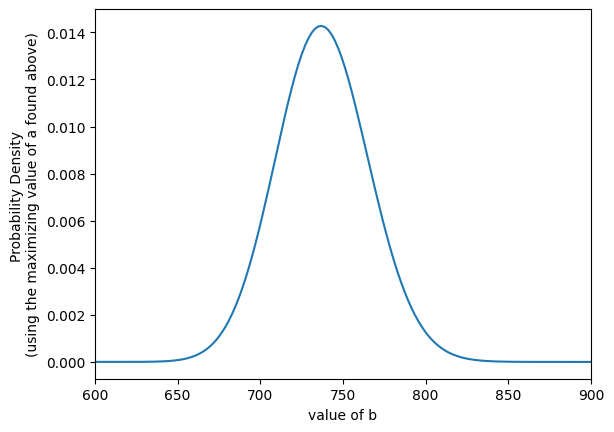

In [25]:
plt.plot(b_list,[prob_prof_L(b) for b in b_list])
plt.xlim(600,900)
plt.ylabel('Probability Density \n(using the maximizing value of a found above)')
plt.xlabel('value of b')
# should integrate to 1.


Guess around to find the values of b at which we can integrate (from center) to get 95%.

Interpretation: We're 95% confident that b_true lies within these values of b.

In [26]:
print( brentq(lambda b : prob_prof_L(b) - 0.00208,600, b_list[prof_L==max(prof_L)][0]) )

683.201297912713


In [47]:
quad(prob_prof_L, 
     brentq(lambda b : prob_prof_L(b) - 0.00208, 600, b_list[prof_L==max(prof_L)][0]),
     brentq(lambda b : prob_prof_L(b) - 0.00208, b_list[prof_L==max(prof_L)][0],900))

# 'brentq' 
# guess that y= 0.00208 is what gives 95% interval, solve for the values of x. Then check.
# What's printed: the value of the integral and some error on the integral result

/tmp/ipykernel_2848709/2585168290.py:1: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  quad(prob_prof_L,brentq(lambda b : prob_prof_L(b) - 0.00208,600,b_list[prof_L==max(prof_L)][0]),brentq(lambda b : prob_prof_L(b) - 0.00208,b_list[prof_L==max(prof_L)][0],900))


(0.9516419142302782, 8.482401936737993e-06)

Evaluate min, max, and most likely

What's printed: the values you'd see in the signal box given each value of b, along with the value of a that maximizes liklihood for that value of b.

In [48]:
brentq(lambda b : prob_prof_L(b) - 0.00208,600,b_list[prof_L==max(prof_L)][0]) * x_sig[0]+ a_max[abs(b_list - 688.94472362) < 0.01]  * x_bkg[0]

array([1235.79953741])

In [49]:
brentq(lambda b : prob_prof_L(b) - 0.00208,b_list[prof_L==max(prof_L)][0],900) * x_sig[0]+ a_max[abs(b_list - 799.49748744) < 0.01]  * x_bkg[0]

array([1440.1050431])

In [50]:
b_list[prof_L == max(prof_L)] * x_sig[0] + a_max[prof_L == max(prof_L)] * x_bkg[0]

array([1335.16079669])

In [51]:
x[0]

1446

In [52]:
(2./3.) * x_bkg[0] + 750 * x_sig[0]

1424.2712573642548